# Classification Modeling

## Goal

Predict whether a public transport trip will be delayed using:

- Weather conditions
- Traffic conditions
- Event information
- Route information
- Schedule information

Target:
- delayed (0 = On Time, 1 = Delayed)

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/public_transport_delays.csv")

df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,3,Storm,5.1,52,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,9,Rain,34.0,64,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,0,Clear,29.5,35,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,10,Clear,27.4,55,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,14,Snow,0.1,90,30,18.5,NaN,500,46,0,0,6,Spring,1


In [3]:
df["event_type"] = df["event_type"].fillna("No_Event")

In [4]:
df["date"] = pd.to_datetime(df["date"])

df["day"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"].isin([5, 6])
).astype(int)

df["scheduled_departure"] = pd.to_datetime(
    df["scheduled_departure"],
    format="%H:%M:%S"
)

df["scheduled_arrival"] = pd.to_datetime(
    df["scheduled_arrival"],
    format="%H:%M:%S"
)

df["scheduled_trip_duration"] = (
    df["scheduled_arrival"] -
    df["scheduled_departure"]
).dt.total_seconds() / 60

df["departure_hour"] = df["scheduled_departure"].dt.hour

df["departure_minute"] = df["scheduled_departure"].dt.minute

df["arrival_hour"] = df["scheduled_arrival"].dt.hour

In [5]:
drop_cols = [
    "trip_id",

    "date",
    "time",

    "scheduled_departure",
    "scheduled_arrival",

    "actual_departure_delay_min",
    "actual_arrival_delay_min"
]

classification_df = df.drop(columns=drop_cols)

classification_df.shape

(2000, 24)

In [6]:
X = classification_df.drop(columns=["delayed"])

y = classification_df["delayed"]

print(X.shape)
print(y.shape)

(2000, 23)
(2000,)


In [7]:
classification_df.shape
X.shape
y.shape

(2000,)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 23)
X_test : (400, 23)
y_train: (1600,)
y_test : (400,)


In [9]:
categorical_features = [
    "transport_type",
    "route_id",
    "origin_station",
    "destination_station",
    "weather_condition",
    "event_type",
    "season"
]

numerical_features = [
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "event_attendance_est",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "weekday",
    "day",
    "day_of_week",
    "is_weekend",
    "departure_hour",
    "departure_minute",
    "arrival_hour",
    "scheduled_trip_duration"
]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [11]:
from sklearn.linear_model import LogisticRegression

In [12]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [13]:
logreg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [14]:
y_pred = logreg_pipeline.predict(X_test)

y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

In [15]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")
print(f"ROC AUC  : {roc_auc:.3f}")

Accuracy : 0.735
Precision: 0.749
Recall   : 0.973
F1 Score : 0.846
ROC AUC  : 0.446


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  2  98]
 [  8 292]]


# Random Forest Classifier

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [19]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [20]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

In [21]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print(f"Accuracy : {rf_accuracy:.3f}")
print(f"Precision: {rf_precision:.3f}")
print(f"Recall   : {rf_recall:.3f}")
print(f"F1 Score : {rf_f1:.3f}")
print(f"ROC AUC  : {rf_auc:.3f}")

Accuracy : 0.750
Precision: 0.750
Recall   : 1.000
F1 Score : 0.857
ROC AUC  : 0.481


In [22]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

print(cm)

[[  0 100]
 [  0 300]]


In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        rf_precision
    ],
    "Recall": [
        recall,
        rf_recall
    ],
    "F1": [
        f1,
        rf_f1
    ],
    "ROC_AUC": [
        roc_auc,
        rf_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.735,0.748718,0.973333,0.846377,0.446433
1,Random Forest,0.750,0.750000,1.000000,0.857143,0.481033


In [24]:
rf_model = rf_pipeline.named_steps["model"]

rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

len(feature_names)

156

In [26]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
140,num__temperature_C,0.053217
145,num__traffic_congestion_index,0.051398
143,num__precipitation_mm,0.051289
142,num__wind_speed_kmh,0.050856
141,num__humidity_percent,0.050124
155,num__scheduled_trip_duration,0.048618
153,num__departure_minute,0.042573
152,num__departure_hour,0.039967
154,num__arrival_hour,0.039330
149,num__day,0.037473


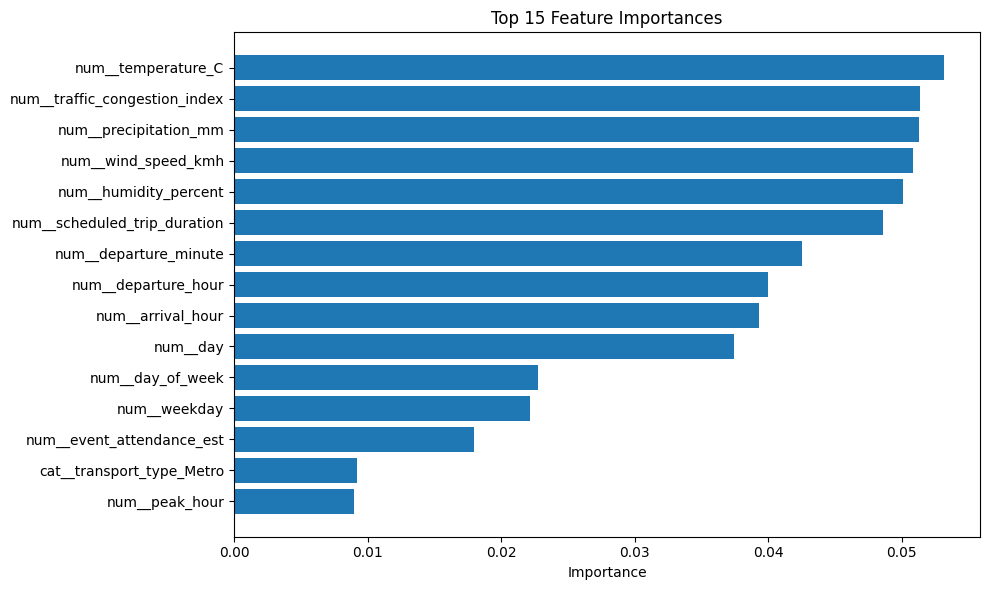

In [27]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(
    "Top 15 Feature Importances"
)

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [28]:
importance_df.head(15)

,feature,importance
140,num__temperature_C,0.053217
145,num__traffic_congestion_index,0.051398
143,num__precipitation_mm,0.051289
142,num__wind_speed_kmh,0.050856
141,num__humidity_percent,0.050124
155,num__scheduled_trip_duration,0.048618
153,num__departure_minute,0.042573
152,num__departure_hour,0.039967
154,num__arrival_hour,0.039330
149,num__day,0.037473


# Final Model Conclusions

## Regression Results

| Model | MAE | RMSE | R² |
|--------|--------|--------|--------|
| Linear Regression | 7.963 | 9.554 | -0.083 |
| Random Forest Regressor | 7.888 | 9.416 | -0.051 |

## Classification Results

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---------|---------|---------|---------|---------|---------|
| Logistic Regression | 0.735 | 0.749 | 0.973 | 0.846 | 0.446 |
| Random Forest Classifier | 0.750 | 0.750 | 1.000 | 0.857 | 0.481 |

## Key Findings

- Dataset contains weak predictive signal.
- Weather and scheduling features were ranked most important by Random Forest.
- Models struggled to distinguish delayed vs non-delayed trips.
- ROC-AUC remained below 0.5 across tested models.
- Multiple modeling approaches produced similar conclusions.

# Save Trained Model

In [29]:
import joblib

In [30]:
joblib.dump(
    rf_pipeline,
    "../models/transit_iq_classifier.pkl"
)

['../models/transit_iq_classifier.pkl']

In [31]:
import os

os.listdir("../models")

['transit_iq_classifier.pkl']